# Visualisation (EDA)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import label

In [3]:
df_1 = pd.read_csv("../data/fraudTrain.csv", sep=",")
df_2 = pd.read_csv("../data/fraudTest.csv", sep=",")
df_2 = df_2[df_2["is_fraud"] != 0] # Permet de prendre que les fraudes
df = pd.concat([df_1, df_2], axis=0, ignore_index=True) # Fusionne les datasets en ajoutant les ligne de df_2

Pour le modèle non supervisé, on décide d'augmenter la part de vraie fraude dans le dataset

In [4]:
df["is_fraud"].value_counts(normalize=True)

is_fraud
0    0.992569
1    0.007431
Name: proportion, dtype: float64

On remarque qu'on a un dataset très déséquilibré 1% de fraude

In [5]:
df.sample(5) # Affichage aléatoire de 5 lignes du DF. Plus pertinent que head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1089513,1089513,2020-03-29 08:28:33,630451534402,fraud_Padberg-Welch,grocery_pos,107.45,Rachel,Daniels,F,561 Little Plain Apt. 738,...,46.3535,-86.6345,765,Immunologist,1972-06-12,673bb981fa2031ee755e8d6b69cbfad4,1364545713,46.053522,-87.248489,0
91637,91637,2019-02-24 03:18:33,4755696071492,"fraud_Heller, Gutmann and Zieme",grocery_pos,64.69,Robert,Evans,M,01892 Patricia Vista Apt. 828,...,32.9643,-96.6012,20328,Site engineer,1985-06-20,8f16506f1d9129dfb336c1c3aa5209b1,1330053513,32.810145,-96.485916,0
510776,510776,2019-08-09 20:52:41,3541687240161491,fraud_Kilback LLC,food_dining,16.40,Mark,Nguyen,M,62631 Ashley Ramp Apt. 965,...,31.1989,-81.3322,298,"Engineer, structural",1963-04-22,f036c8cfb242cf2401826a0fdc0bfbd9,1344545561,30.443127,-81.588674,0
982375,982375,2020-02-03 11:04:40,180049032966888,fraud_Kassulke PLC,shopping_net,88.40,Michael,Flores,M,70761 Fitzpatrick Brooks Suite 631,...,46.4959,-90.4383,795,Television/film/video producer,1986-04-15,a2f385ee01a58ef4ab75b23a7160035e,1359889480,47.328691,-91.021620,0
33252,33252,2019-01-20 20:11:08,6011104316292105,fraud_Klein Group,entertainment,5.29,Valerie,Davis,F,3861 Anderson Ramp Apt. 536,...,36.9688,-78.5615,1970,Energy engineer,1985-09-02,6f55720ed035315e076c413b1b57e89c,1327090268,37.093454,-79.388834,0


In [6]:
df.drop(["merch_lat","merch_long","lat","long",'Unnamed: 0','trans_num','cc_num','last','first','street'], axis=1, inplace=True)

Suppression des colonnes qui vont faire du bruit dans le modèle

<Axes: ylabel='count'>

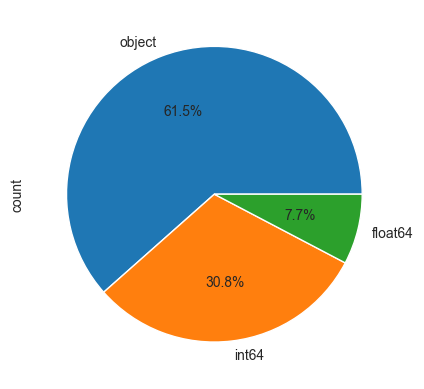

In [7]:
df.dtypes.value_counts().plot.pie(autopct='%1.1f%%')

Le dataset contient une majorité d'objet

In [8]:
print(df.duplicated().sum().sum())

0


Pas de valeur dupliquées

In [9]:
df.describe(include="all")

,trans_date_trans_time,merchant,category,amt,gender,city,state,zip,city_pop,job,dob,unix_time,is_fraud
count,1298820,1298820,1298820,1.298820e+06,1298820,1298820,1298820,1.298820e+06,1.298820e+06,1298820,1298820,1.298820e+06,1.298820e+06
unique,1276936,693,14,NaN,2,906,51,NaN,NaN,497,984,NaN,NaN
top,2019-04-22 16:02:01,fraud_Kilback LLC,gas_transport,NaN,F,Birmingham,TX,NaN,NaN,Film/video editor,1977-03-23,NaN,NaN
freq,4,4418,131813,NaN,711027,5642,94989,NaN,NaN,9787,5651,NaN,NaN
mean,NaN,NaN,NaN,7.110743e+01,NaN,NaN,NaN,4.879912e+04,8.878432e+04,NaN,NaN,1.349294e+09,7.430591e-03
std,NaN,NaN,NaN,1.620471e+02,NaN,NaN,NaN,2.689293e+04,3.018400e+05,NaN,NaN,1.289102e+07,8.588005e-02
min,NaN,NaN,NaN,1.000000e+00,NaN,NaN,NaN,1.257000e+03,2.300000e+01,NaN,NaN,1.325376e+09,0.000000e+00
25%,NaN,NaN,NaN,9.660000e+00,NaN,NaN,NaN,2.623700e+04,7.430000e+02,NaN,NaN,1.338761e+09,0.000000e+00
50%,NaN,NaN,NaN,4.758000e+01,NaN,NaN,NaN,4.817400e+04,2.456000e+03,NaN,NaN,1.349296e+09,0.000000e+00
75%,NaN,NaN,NaN,8.331000e+01,NaN,NaN,NaN,7.201100e+04,2.032800e+04,NaN,NaN,1.359494e+09,0.000000e+00


On distingue qu'il n'y a pas de valeur manquante

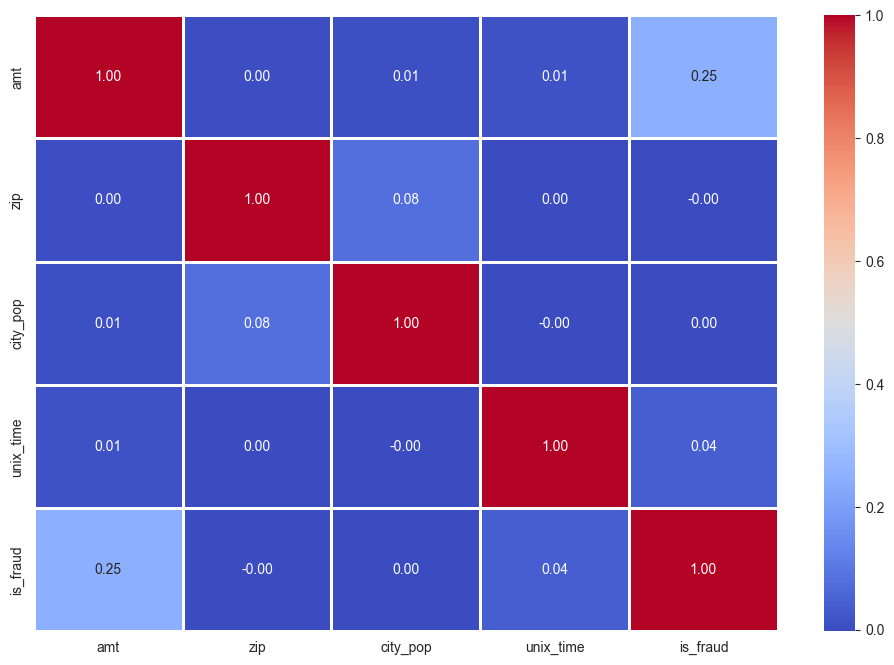

In [10]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
#kot = corr[(corr !=1.000) & ((corr >=0.4) | (corr <=(-0.2)))]
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=1,
            )
plt.show()

Pas de corrélation entre nos données quantitative

# Preprocessing

In [11]:
# Prétraitement
from sklearn.preprocessing import StandardScaler, MinMaxScaler,LabelEncoder,OrdinalEncoder,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

On peut déduire l'age de la personne qui a déclaré la fraude avec sa date de naissance et le timestamp du moment de la fraude.

On supprimer **trans_date_trans_time** car on a unix_time qui represe

In [16]:
df_sav = df.copy()

Sauvegarde du Dataset

In [17]:
numeric_features = ["amt", "zip", "city_pop", "age_at_transaction",'trans_date_trans_time_timestamp']
categorical_features_non_ord = ["state", "city","gender","category","merchant","job"]

Definition des valeurs garder pour le preprocessing dans la Pipeline

In [ ]:
from transformers_ML import TransactionDateTransformer

In [18]:
# Transformer personnalisé
date_transformer = TransactionDateTransformer()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()) # on évite qu’une variable domine les autres en reduisant leur echélle
])

categorical_non_ord_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1
    ))# Si une nouvelle catégorie apparaît, ne plante pas( handle_unknown='use_encoded_value', unknown_value=-1)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_non_ord_transformer, categorical_features_non_ord)
    ],
    remainder="drop"
)

In [19]:
date_transformer.fit_transform(df)

D:\Etude\Master cours\Data science\data-sc-env\projet-detection-fraude\eda\transformers.py:43: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  X['trans_date_trans_time_timestamp'] = X[self.trans_date_col].view('int64') // 10 ** 9


,merchant,category,amt,gender,city,state,zip,city_pop,job,unix_time,is_fraud,age_at_transaction,trans_date_trans_time_timestamp
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,28654,3495,"Psychologist, counselling",1325376018,0,31,1546300818
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,99160,149,Special educational needs teacher,1325376044,0,41,1546300844
2,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,83252,4154,Nature conservation officer,1325376051,0,57,1546300851
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,59632,1939,Patent attorney,1325376076,0,52,1546300876
4,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,24433,99,Dance movement psychotherapist,1325376186,0,33,1546300986
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298815,"fraud_Willms, Kris and Bergnaum",shopping_pos,1041.51,M,Senatobia,MS,38668,14462,Database administrator,1387749948,1,62,1608674748
1298816,fraud_Kuhn LLC,shopping_pos,868.09,M,Senatobia,MS,38668,14462,Database administrator,1387750687,1,62,1608675487
1298817,"fraud_Mosciski, Ziemann and Farrell",shopping_net,1039.42,M,Senatobia,MS,38668,14462,Database administrator,1387751508,1,62,1608676308
1298818,fraud_Bauch-Raynor,grocery_pos,289.27,M,Senatobia,MS,38668,14462,Database administrator,1387753563,1,62,1608678363


In [20]:
df.drop('is_fraud', axis=1, inplace=True)

Suppression de la colonne qui contient les réponses de notre DF

In [21]:
# Modèles de Machine Learning
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor,IsolationForest

In [22]:
# Modele isolation forest pour
model_IsoForest = IsolationForest(
    n_estimators=100, # Nombre d'arbre
    contamination=0.01, # On cible les 1% de fraude
    max_samples='auto', # nombre d’échantillons utilisés pour construire chaque arbre de l’ensemble
    random_state=42, # Pour la reproductibilité de l’aléatoire
    n_jobs=-1 # Utilisation de tout les coeurs
)

# Pipeline uniquement pour le nettoyage
preprocessor_pipe = Pipeline([
    ("date_transform", date_transformer),
    ('preprocessor', preprocessor)
])

# On transforme les données
X_transformed = preprocessor_pipe.fit_transform(df)

D:\Etude\Master cours\Data science\data-sc-env\projet-detection-fraude\eda\transformers.py:43: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  X['trans_date_trans_time_timestamp'] = X[self.trans_date_col].view('int64') // 10 ** 9


In [23]:
X_transformed

array([[-4.08137151e-01, -7.49086431e-01, -2.82564813e-01, ...,
         8.00000000e+00,  5.14000000e+02,  3.72000000e+02],
       [ 2.22914047e-01,  1.87264437e+00, -2.93650162e-01, ...,
         4.00000000e+00,  2.41000000e+02,  4.31000000e+02],
       [ 9.19501756e-01,  1.28111325e+00, -2.80381536e-01, ...,
         0.00000000e+00,  3.90000000e+02,  3.08000000e+02],
       ...,
       [ 5.97550173e+00, -3.76720784e-01, -2.46230974e-01, ...,
         1.10000000e+01,  4.43000000e+02,  1.19000000e+02],
       [ 1.34629132e+00, -3.76720784e-01, -2.46230974e-01, ...,
         4.00000000e+00,  2.90000000e+01,  1.19000000e+02],
       [ 4.29055924e+00, -3.76720784e-01, -2.46230974e-01, ...,
         8.00000000e+00,  2.81000000e+02,  1.19000000e+02]],
      shape=(1298820, 11))

In [24]:
model_IsoForest.fit(X_transformed) # Entrainement du modéle
y_pred = model_IsoForest.predict(X_transformed) # Prediction du modéle

In [25]:
df_final = pd.DataFrame(y_pred, columns=['predictions'])

In [26]:
df_final.value_counts()

predictions
 1             1285831
-1               12989
Name: count, dtype: int64

In [27]:
df_final['predictions'] = df_final['predictions'].map({-1:1,1:0}) # Normalisation des resultats pour ensuite effectuer une comparaison

              precision    recall  f1-score   support

           0       0.99      0.99      0.99   1289169
           1       0.15      0.21      0.17      9651

    accuracy                           0.99   1298820
   macro avg       0.57      0.60      0.58   1298820
weighted avg       0.99      0.99      0.99   1298820



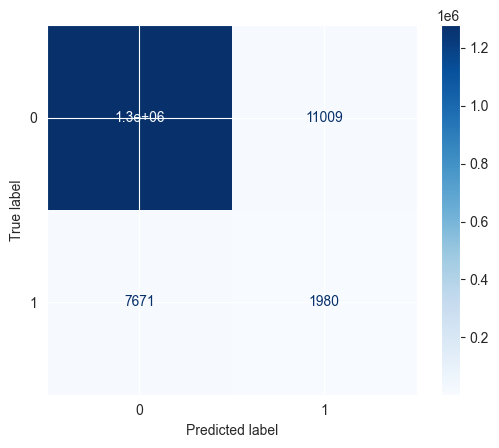

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Afficher les métriques clés (Précision, Rappel, F1-Score)
print(classification_report(df_sav['is_fraud'], df_final['predictions']))

# Visualiser la matrice de confusion de manière pro
# On peut le faire, car nous avons un dataset labelliser
ConfusionMatrixDisplay.from_predictions(df_sav['is_fraud'], df_final['predictions'],cmap='Blues')

## On peut le faire, car nous avons un dataset labelliser
Le modèle n'est pas très performant, il détecte que 20% des fraudes, et que 15% des fraudes détecter son réelle.

In [31]:
import joblib
from sklearn.pipeline import Pipeline

# On crée un pipeline qui combine le préprocesseur et le modèle déjà entraîné
# On fait ça pour permettre au fichier .pkl de savoir comment transformer les données avant de prédire
pipe_unsup = Pipeline(steps=[
    ("date_transform", date_transformer),
    ("preprocess", preprocessor),
    ("model", model_IsoForest)
])

# 2. Sauvegarde du pipeline complet en .pkl
joblib.dump(pipe_unsup, '../Models/model_unsup_final.pkl')

print("Modèle et pipeline sauvegardés")

Modèle et pipeline sauvegardés
